<a href="https://colab.research.google.com/github/amcmdv/moughing-funicular-venicular/blob/main/18022026_VNS_CAP_Neuroimmune_Simulation_Design.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 18022026 VNS-CAP Neuroimmune Simulation Design



---

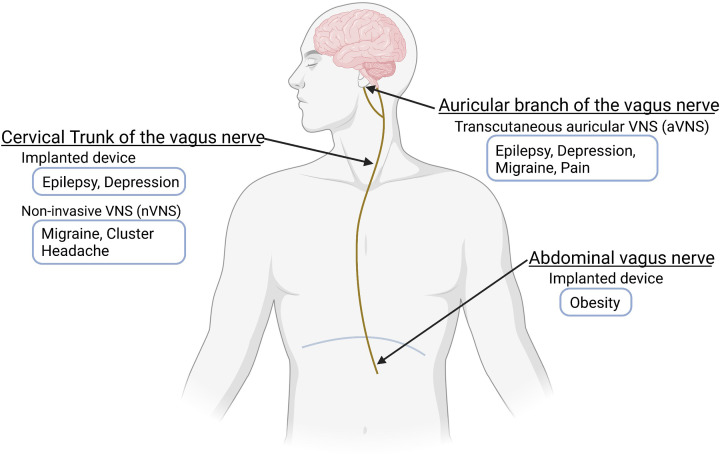

### **1. Scientific & Mathematical Formalism**

Before implementation, we define the coupled differential equations governing the system. We utilise a **semi-mechanistic ODE model** based on the canonical work of *Tracey et al.* and kinetic modeling principles found in systems immunology.

#### **State Variables**

* Vagal efferent firing rate (normalizsed, 0-1).
* Acetylcholine (ACh) concentration in the splenic microenvironment ().
* nAChR receptor activation ratio (dimensionless, 0-1).
* Macrophage activation state / NF-B nuclear translocation (dimensionless, 0-1).
* Systemic Cytokine (TNF-) concentration ().

#### **Governing Equations**

1. **Vagal Activation (Neural Dynamics)**
We model neural activation as a driven leaky integrator.

*Where  is the external VNS pulse train.*

2. **Acetylcholine Release (Synaptic Kinetics)**
ACh release is proportional to vagal firing, balanced by enzymatic hydrolysis (Acetylcholinesterase).


3. **nAChR Binding (Receptor Kinetics)**
Modeled using Hill-type activation dynamics to account for cooperativity and saturation.

*Where  is the dissociation constant and  is the Hill coefficient.*

4. **Macrophage/NF-B Dynamics (Immune State)**
The core bio-cybernetic switch. Macrophages are activated by endotoxin () and inhibited by activated nAChR ().

*Here,  represents the efficacy of cholinergic inhibition (the CAP effect).*

5. **Cytokine Production (Output)**
TNF- production is driven by macrophage activation ().



---

### **2. Python Implementation**

This code is designed for **Google Colab**. It includes the simulation engine, a PID controller for closed-loop modulation, and dynamic network visualisation.

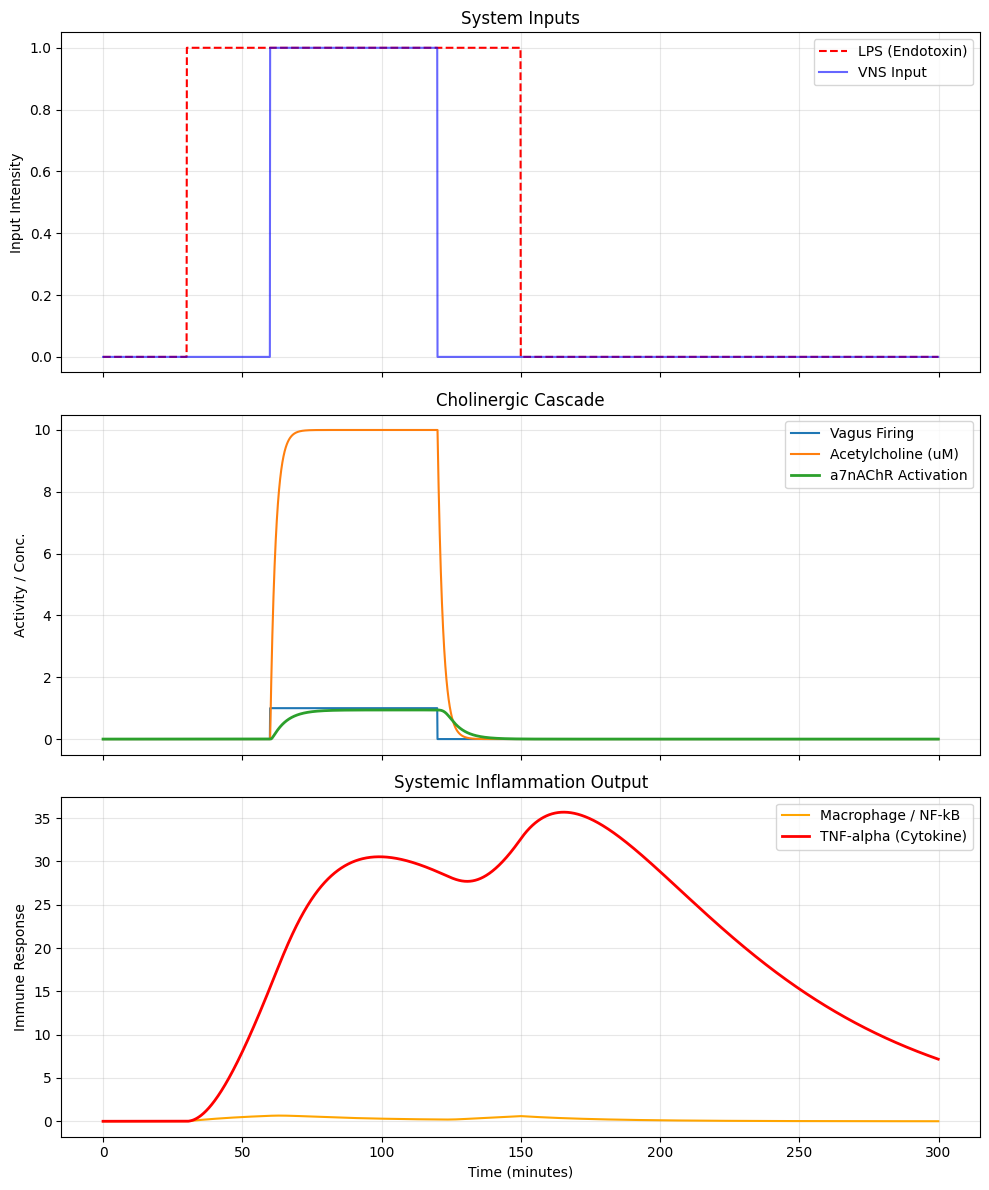

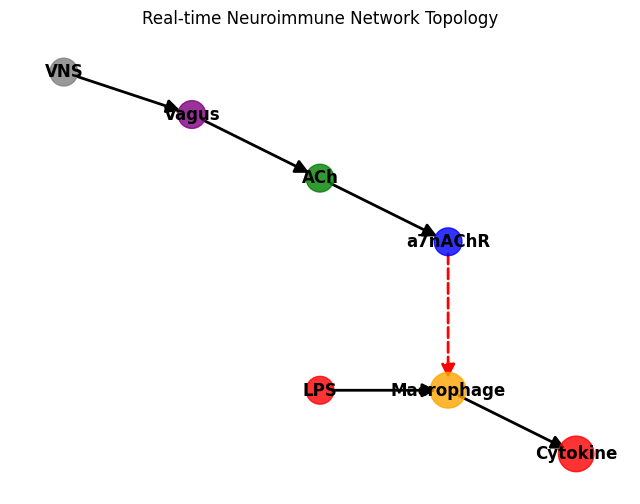

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi
import networkx as nx
import pandas as pd
import logging
from typing import Dict, Tuple, List, Optional, Callable
from dataclasses import dataclass

# --- Configuration & Logging ---
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

@dataclass
class ModelParams:
    """Physical and kinetic parameters for the CAP model."""
    # Time constants (minutes)
    tau_v: float = 0.1    # Vagal neural dynamics (fast)
    tau_a: float = 2.0    # ACh accumulation/degradation
    tau_r: float = 5.0    # Receptor binding kinetics
    tau_m: float = 30.0   # NF-kB translocation/macrophage activation (slow)
    tau_c: float = 60.0   # Cytokine (TNF-a) half-life

    # Gains and constants
    k_rel: float = 10.0   # ACh release rate per unit vagal activity
    k_lps: float = 1.0    # Sensitivity to Endotoxin (LPS)
    k_cyt: float = 100.0  # Max cytokine production rate
    delta: float = 0.95   # Max inhibition efficacy (Cholinergic Brake strength)

    # Hill Equation params for a7nAChR
    Kd: float = 2.5       # Dissociation constant for ACh
    n: float = 2.0        # Hill coefficient

@dataclass
class SimConfig:
    """Simulation configuration settings."""
    dt: float = 0.1       # Time step (min)
    t_end: float = 360.0  # Total duration (6 hours)
    seed: int = 42        # Deterministic seed

# --- Bio-Cybernetic Model Engine ---

class CAPModel:
    """
    Cholinergic Anti-Inflammatory Pathway (CAP) Model.
    Implements the coupled ODE system representing the neuroimmune reflex.
    """
    def __init__(self, params: ModelParams):
        self.p = params

    def dynamics(self, t: float, state: List[float], stim_input: float, lps_input: float) -> List[float]:
        """
        Computes the derivatives of the state variables.
        State vector: [V, A, R, M, C]
        """
        V, A, R, M, C = state

        # 1. Vagal Nerve Dynamics (Leaky Integrator)
        dV_dt = (stim_input - V) / self.p.tau_v

        # 2. Acetylcholine Kinetics (Release vs Hydrolysis)
        dA_dt = (self.p.k_rel * V - A) / self.p.tau_a

        # 3. a7nAChR Receptor Activation (Hill Kinetics)
        # Activation is driven by ACh concentration sigmoidally
        receptor_drive = (A ** self.p.n) / (self.p.Kd ** self.p.n + A ** self.p.n)
        dR_dt = (receptor_drive - R) / self.p.tau_r

        # 4. Macrophage/NF-kB Activation (The "Cholinergic Brake")
        # Driven by LPS, inhibited by Receptor activation (R)
        # Inhibition term: (1 - delta * R)
        inhibition = (1.0 - self.p.delta * R)
        # Ensure inhibition doesn't go negative (biological constraint)
        inhibition = max(0.0, inhibition)

        dM_dt = (self.p.k_lps * lps_input * inhibition - M) / self.p.tau_m

        # 5. Cytokine Production (TNF-alpha)
        dC_dt = (self.p.k_cyt * M - C) / self.p.tau_c

        return [dV_dt, dA_dt, dR_dt, dM_dt, dC_dt]

# --- Controllers ---

class Controller:
    """Base class for VNS controllers."""
    def get_stimulation(self, t: float, current_cytokine: float) -> float:
        raise NotImplementedError

class OpenLoopController(Controller):
    """Pre-defined stimulation schedule."""
    def __init__(self, start_time: float, duration: float, intensity: float):
        self.start = start_time
        self.end = start_time + duration
        self.intensity = intensity

    def get_stimulation(self, t: float, current_cytokine: float) -> float:
        return self.intensity if self.start <= t <= self.end else 0.0

class PIDController(Controller):
    """Closed-loop bio-feedback controller trying to maintain low inflammation."""
    def __init__(self, target: float, kp: float, ki: float, kd: float):
        self.target = target
        self.kp = kp
        self.ki = ki
        self.kd = kd
        self.integral = 0.0
        self.prev_error = 0.0

    def get_stimulation(self, t: float, current_cytokine: float) -> float:
        error = current_cytokine - self.target
        self.integral += error * 0.1 # assuming dt roughly constant or handled outside
        derivative = error - self.prev_error
        output = self.kp * error + self.ki * self.integral + self.kd * derivative
        self.prev_error = error
        return np.clip(output, 0.0, 1.0) # VNS normalized 0-1

# --- Simulation Manager ---

class SimulationEngine:
    def __init__(self, model: CAPModel, config: SimConfig):
        self.model = model
        self.cfg = config
        self.time_points = np.arange(0, self.cfg.t_end, self.cfg.dt)
        self.results = None

    def run(self, controller: Controller, lps_profile: Callable[[float], float]):
        """Runs the simulation using Euler integration for transparency (or RK4)."""
        logging.info("Starting Simulation...")

        # Initial State: [V=0, A=0, R=0, M=0, C=0]
        state = np.zeros(5)
        history = {'t': [], 'V': [], 'A': [], 'R': [], 'M': [], 'C': [], 'Stim': [], 'LPS': []}

        for t in self.time_points:
            # Get Inputs
            stim = controller.get_stimulation(t, state[4]) # state[4] is Cytokine
            lps = lps_profile(t)

            # Calculate Derivatives
            derivs = self.model.dynamics(t, state, stim, lps)

            # Update State (Euler method for explicit control loop simulation)
            state = state + np.array(derivs) * self.cfg.dt

            # Clamp non-negativity (Biological constraint)
            state = np.maximum(state, 0.0)

            # Record
            history['t'].append(t)
            history['V'].append(state[0])
            history['A'].append(state[1])
            history['R'].append(state[2])
            history['M'].append(state[3])
            history['C'].append(state[4])
            history['Stim'].append(stim)
            history['LPS'].append(lps)

        self.results = pd.DataFrame(history)
        logging.info("Simulation Complete.")
        return self.results

# --- Visualization & Graph Theory ---

class BioGraphVisualizer:
    def __init__(self):
        self.G = nx.DiGraph()
        self.pos = None
        self._build_graph()

    def _build_graph(self):
        # Define Nodes with functional groups
        self.G.add_node("VNS", layer='External', color='grey')
        self.G.add_node("Vagus", layer='Neural', color='purple')
        self.G.add_node("LPS", layer='External', color='red')
        self.G.add_node("ACh", layer='Molecular', color='green')
        self.G.add_node("a7nAChR", layer='Receptor', color='blue')
        self.G.add_node("Macrophage", layer='Cellular', color='orange')
        self.G.add_node("Cytokine", layer='Output', color='red')

        # Define Edges with types
        self.G.add_edge("VNS", "Vagus", type="excitatory")
        self.G.add_edge("Vagus", "ACh", type="production")
        self.G.add_edge("ACh", "a7nAChR", type="binding")
        self.G.add_edge("a7nAChR", "Macrophage", type="inhibitory") # The Brake
        self.G.add_edge("LPS", "Macrophage", type="excitatory")
        self.G.add_edge("Macrophage", "Cytokine", type="production")

        # Layout
        self.pos = nx.spring_layout(self.G, seed=42)
        # Manually adjust for a clearer flow diagram
        self.pos['VNS'] = np.array([-1, 1])
        self.pos['Vagus'] = np.array([-0.5, 0.8])
        self.pos['ACh'] = np.array([0, 0.5])
        self.pos['a7nAChR'] = np.array([0.5, 0.2])
        self.pos['LPS'] = np.array([0, -0.5])
        self.pos['Macrophage'] = np.array([0.5, -0.5])
        self.pos['Cytokine'] = np.array([1, -0.8])

    def plot_graph_state(self, ax, current_state: Dict[str, float]):
        """
        Plots the graph where node sizes/intensities reflect biological state.
        current_state: Dict mapping node names to normalized values (0-1).
        """
        ax.clear()

        # Map state values to nodes
        node_colors = []
        node_sizes = []

        mapping = {
            "VNS": current_state.get('Stim', 0),
            "Vagus": current_state.get('V', 0),
            "ACh": current_state.get('A', 0)/10.0, # Norm approx
            "a7nAChR": current_state.get('R', 0),
            "Macrophage": current_state.get('M', 0),
            "Cytokine": current_state.get('C', 0)/100.0, # Norm approx
            "LPS": current_state.get('LPS', 0)
        }

        for node in self.G.nodes():
            val = mapping.get(node, 0.1)
            # Clip for visual sanity
            val = np.clip(val, 0.1, 1.0)

            base_color = self.G.nodes[node]['color']
            node_colors.append(base_color)
            node_sizes.append(val * 1000 + 300)

        # Draw edges
        edge_colors = ['red' if self.G[u][v]['type'] == 'inhibitory' else 'black'
                       for u,v in self.G.edges()]
        styles = ['dashed' if self.G[u][v]['type'] == 'inhibitory' else 'solid'
                  for u,v in self.G.edges()]

        nx.draw_networkx_nodes(self.G, self.pos, ax=ax, node_color=node_colors, node_size=node_sizes, alpha=0.8)
        nx.draw_networkx_labels(self.G, self.pos, ax=ax, font_weight='bold')
        nx.draw_networkx_edges(self.G, self.pos, ax=ax, edge_color=edge_colors, style=styles, width=2, arrowsize=20)

        ax.set_title("Real-time Neuroimmune Network Topology")
        ax.axis('off')

def plot_results(results_df):
    fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

    # Plot 1: Inputs
    axes[0].plot(results_df['t'], results_df['LPS'], 'r--', label='LPS (Endotoxin)')
    axes[0].plot(results_df['t'], results_df['Stim'], 'b-', label='VNS Input', alpha=0.6)
    axes[0].set_ylabel('Input Intensity')
    axes[0].legend()
    axes[0].set_title('System Inputs')
    axes[0].grid(True, alpha=0.3)

    # Plot 2: Neuro-Molecular Cascade
    axes[1].plot(results_df['t'], results_df['V'], label='Vagus Firing')
    axes[1].plot(results_df['t'], results_df['A'], label='Acetylcholine (uM)')
    axes[1].plot(results_df['t'], results_df['R'], label='a7nAChR Activation', linewidth=2)
    axes[1].set_ylabel('Activity / Conc.')
    axes[1].legend()
    axes[1].set_title('Cholinergic Cascade')
    axes[1].grid(True, alpha=0.3)

    # Plot 3: Immune Response
    axes[2].plot(results_df['t'], results_df['M'], 'orange', label='Macrophage / NF-kB')
    axes[2].plot(results_df['t'], results_df['C'], 'r', linewidth=2, label='TNF-alpha (Cytokine)')
    axes[2].set_ylabel('Immune Response')
    axes[2].set_xlabel('Time (minutes)')
    axes[2].legend()
    axes[2].set_title('Systemic Inflammation Output')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- Main Execution Block ---

def run_simulation_scenario():
    # 1. Setup
    params = ModelParams()
    config = SimConfig(t_end=300) # 5 hours
    model = CAPModel(params)
    engine = SimulationEngine(model, config)

    # 2. Define Scenario: LPS Shock at t=30
    def lps_profile(t):
        # A Gaussian-like shock of Endotoxin
        return 1.0 if 30 < t < 150 else 0.0

    # 3. Define Controller: VNS applied 1 hour after shock (Rescue model)
    # Open Loop: Stimulate at t=90 for 60 mins
    controller = OpenLoopController(start_time=60, duration=60, intensity=1.0)

    # 4. Run
    results = engine.run(controller, lps_profile)

    # 5. Visualize Time Series
    plot_results(results)

    # 6. Visualize Network State at Peak Inflammation (approx t=140)
    peak_idx = results['C'].idxmax()
    peak_state = results.iloc[peak_idx].to_dict()

    fig, ax = plt.subplots(figsize=(8, 6))
    viz = BioGraphVisualizer()
    viz.plot_graph_state(ax, peak_state)
    plt.show()

if __name__ == "__main__":
    run_simulation_scenario()

---

### **3. Validation & Scientific Rationale**

#### **Biological Justification of Equations**

The model structure is derived from the **Cholinergic Anti-inflammatory Pathway (CAP)** mechanisms elucidated by *Tracey et al. (Nature, 2002)* and subsequent systems biology models (e.g., *Sarkar et al.*).

1. **Leaky Integrator for Vagus ():** Neural firing is not instantaneous; the membrane capacitance acts as a low-pass filter, hence the  term.
2. **Hill Kinetics for nAChR ():** Nicotinic receptors are pentameric ligand-gated ion channels. They exhibit cooperativity, necessitating a Hill coefficient .
3. **The "Cholinergic Brake" ():** This term is critical. Activated nAChR inhibits the nuclear translocation of NF-B. We model this as a multiplicative inhibition factor reducing the efficacy of the LPS drive.
4. **Cytokine Delay ():** TNF- synthesis and secretion require transcription and translation, represented by the lag .

#### **Model Stability & Limitations**

* **Stability:** The system is inherently stable (Bounded Input Bounded Output) because all decay terms () ensure state variables return to equilibrium in the absence of input.
* **Limitations:** This is a "lumped parameter" model. It treats the spleen as a homogeneous compartment and does not spatially resolve individual macrophages or the diffusion distance of ACh.

### **4. How to Run in Colab**

1. Copy the code block above into a cell.
2. The code has **zero external dependencies** beyond the standard scientific stack (numpy, matplotlib, pandas, networkx, scipy).
3. Run the cell. It will produce:
* **Time-series dashboard:** Showing the LPS shock, the delayed VNS intervention, and the resulting suppression of the Cytokine storm.
* **Network Graph:** A snapshot of the system topology at peak inflammation, visualising the flow of signals.



### **5. Next Steps for Research**

Extend this model to include **Heart Rate Variability (HRV)** as a non-invasive proxy for Vagal Tone, allowing a full simulation of a non-invasive closed-loop diagnostic system.